# get bachground density rho_s based on Winters et al. 1995

In [ ]:
# May 12. Expand to whole domain, not just the Sulu Sea

# May 19. get the data fro the Sulu Sea and Celebes Sea seperately

# May 27. Recheck the z_star and remove a few useless cells.

# June 23. Tsorted_2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xmitgcm 
import os
from tqdm import tqdm
%matplotlib inline
import scipy
from scipy.signal import butter, filtfilt

# NOTES and python code for data processing:
# this is the main script to process the data, including:

In [3]:
# 0. intialize zarr dataset (00_init_zarr.py)
%run 00_init_zarr.py

Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/u.zarr
Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/v.zarr
Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/phihyd.zarr
Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/theta.zarr
Done.


In [ ]:
# 1. write the data (u, v, theta, phihyd) to the zarr dataset (01_write_mds_to_zarr.py) using slurm (sbatch run_01_write_mds_to_zarr.sh)
# 2. get baroclinic part of pressure and velocity
#   2.0 get the pressure (baroclinic) data (02_get_pressure_bc.py) using slurm (sbatch run_02_get_pressure.sh)
#   2.1 get velocity (baroclinic) data (02_1_get_velocity_bc.py) using slurm (sbatch run_02_1_get_velocity_bc.sh)
#   2.2 get rho data (022_get_rho.py) using slurm (sbatch run_022_get_rho.sh)

# got the the following cells to check the data

In [ ]:
# 3. highpass u, v, and pressure (cutoff period = 16 hours) 
#   3.0 initialize high-passed velocity
%run 03_0_init_highpass_velocity_zarr.py
#   3.1 apply high-pass filter to the velocity data (03_1_highpass_velocity_zarr.py) by slurm (sbatch run_03_1_highpass_velocity_zarr.sh)
#   3.2 apply high-pass filter to the pressure data (03_2_highpass_pressure_zarr.py) by slurm (sbatch run_03_2_highpass_pressure_zarr.sh)

# 4. get energy fluxes (04_get_energy_flux.py) by slurm (sbatch run_04_get_energy_flux.sh)
# 5. get vertical integrated energy fluxes xdir (05_get_energy_vert_int_fx.py) and ydir (05_get_energy_vert_int_fy.py) 
#       by slurm (sbatch run_05_get_vert_int_energy_flux.sh)


Already exists, skipping: /home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/u_bc_highpass.zarr
Already exists, skipping: /home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/v_bc_highpass.zarr
Initialized /home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/p_rho_bc_highpass.zarr  shape=(600,87,1908,1520)  chunks=(20, 10, 128, 128)
Done. You can now submit 03_1_run_highpass_velocity_zarr.sh safely.


In [ ]:
# GET energy fluxex by KE and PE
# 6. get kinetic energy (06_get_ke_from_ubc_hp.py) by slurm (sbatch run_06_get_ke_from_ubc_hp.sh)
# 7. get APE 
#   7.0 ref rho (07_0_get_background_den_profile_87layers_v3.py) by slurm (sbatch 07_0_run_get_background_den_profile_87layers.sh)
#   7.1 get APE (07_1_get_local_zstar.py) by slurm (sbatch run_07_1_get_local_zstar.sh)
#   7.2 get APE fluxes (072_get_ape_flux_from_rho.py) by slurm (sbatch run_072_get_ape_flux_from_rho.sh)

# 1. prepare constants and functions

In [2]:
# parameters for EOS equation of state
rho0 = 1026.5
T0 = 5
alpha = 2e-4
g=9.81

CASE_DIR = '/home/ceoas/liux8/work/basin_modes/sulu_sea/ctrl_tests/case_ctrl_bot_intensify_Tsorted_2'
data_dir = '/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/ctrl_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output'

ds_grid = xmitgcm.open_mdsdataset(CASE_DIR, prefix = 'outs_sn', iters=[0] )

lon = ds_grid.XC
lat = ds_grid.YC

# 2. load data and pick up a zonal section for testing



In [3]:
theta = xr.open_zarr(os.path.join(data_dir, 'theta.zarr'), consolidated=False)

In [4]:
# coordinates and grid info for the section
# ds = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/', prefix=['outs_sn'], iters=[0])
ds = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/ctrl_tests/case_ctrl_bot_intensify_Tsorted_2/', prefix=['outs_sn'], iters=[0])

# lon_sec = ds.XC.isel(XC=slice(570,970)).values
# lat_sec = ds.YC.isel(YC=slice(1100, 1101)).values
z_centers = ds.Z.values
# z_faces = ds.Zl.values
drF = ds.drF.values
hFacS = ds.hFacS.values
hFacW = ds.hFacW.values
# drC = ds.drC.values
# rA = ds.rA.isel(YC=slice(1100, 1101), XC=slice(570,970)).values
# hFacC = ds.hFacC.isel(YC=slice(1100, 1101), XC=slice(570,970)).values

In [8]:
t00 = theta.theta.isel(time = 0, x=700, y=1100).values
t00[t00==0] = np.nan

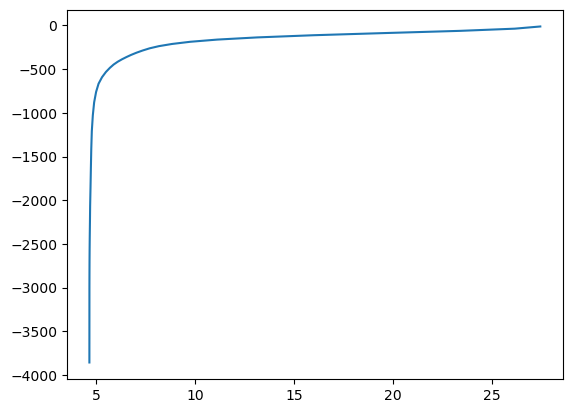

In [11]:
plt.plot(t00, z_centers)
# plt.xlim(4.66,4.67)

## 2.1 get velcity and check the spectrum of the velocity at one location

In [56]:
u = xr.open_zarr(os.path.join(data_dir, 'u.zarr'), consolidated=False)
v = xr.open_zarr(os.path.join(data_dir, 'v.zarr'), consolidated=False)
u_bc = xr.open_zarr(os.path.join(data_dir, 'u_bc.zarr'), consolidated=False)
v_bc = xr.open_zarr(os.path.join(data_dir, 'v_bc.zarr'), consolidated=False)
u_bc_hp = xr.open_zarr(os.path.join(data_dir, 'u_bc_highpass.zarr'), consolidated=False)
v_bc_hp = xr.open_zarr(os.path.join(data_dir, 'v_bc_highpass.zarr'), consolidated=False)
p_bc = xr.open_zarr(os.path.join(data_dir, 'p_rho_bc.zarr'), consolidated=False)
p_bc_hp = xr.open_zarr(os.path.join(data_dir, 'p_rho_bc_highpass.zarr'), consolidated=False)
rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)


In [57]:
u_sulu = u.u.isel(y =1100, x=700)
u_bc_sulu = u_bc.u_bc.isel(y =1100, x=700)
v_bc_sulu = v_bc.v_bc.isel(y =1100, x=700)
u_bc_hp_sulu = u_bc_hp.u_bc_highpass.isel(y =1100, x=700)
v_bc_hp_sulu = v_bc_hp.v_bc_highpass.isel(y =1100, x=700)
p_bc_sulu = p_bc.p_rho_bc.isel(y =1100, x=700)
p_bc_hp_sulu = p_bc_hp.p_rho_bc_highpass.isel(y =1100, x=700)
rho_sulu = rho.rho.isel(y =1100, x=700)

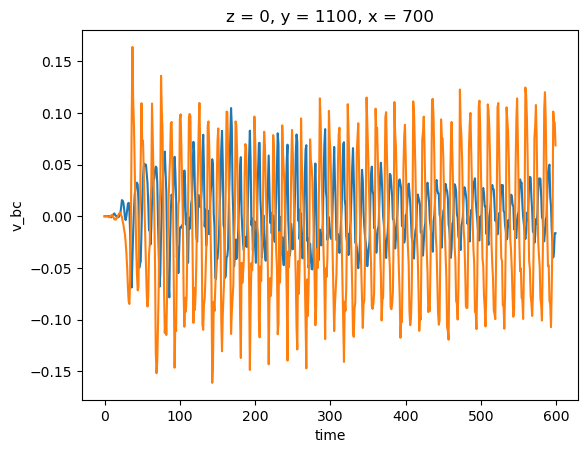

In [61]:
# save the data to netcdf
u_bc_sulu_p1 = u_bc_sulu.isel(z=0)
v_bc_sulu_p1 = v_bc_sulu.isel(z=0)
u_bc_sulu_p1.plot()
v_bc_sulu_p1.plot()

xr.Dataset({'u_bc_sulu_p1': u_bc_sulu_p1, 'v_bc_sulu_p1': v_bc_sulu_p1}).to_netcdf(os.path.join(data_dir, 'u_v_bc_sulu_p1.nc'))

(200.0, 250.0)

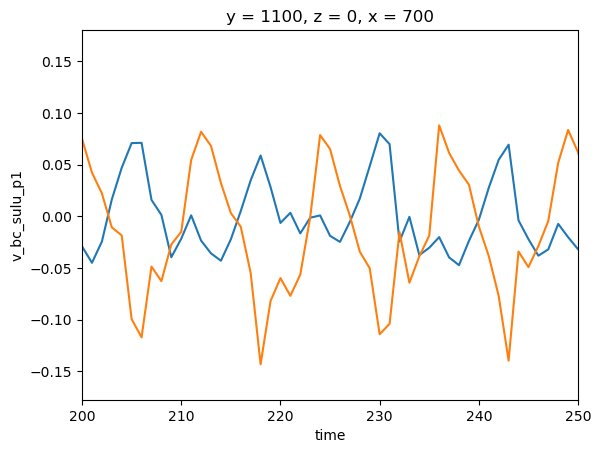

In [89]:
uv_n1 = xr.open_dataset(os.path.join(data_dir, 'u_v_bc_sulu_p1.nc'))
uv_n1.u_bc_sulu_p1.plot()
uv_n1.v_bc_sulu_p1.plot()
plt.xlim(200,250)

In [91]:
uv_n1


<xarray.Dataset> Size: 7kB
Dimensions:       (time: 600)
Coordinates:
  * time          (time) int32 2kB 0 1 2 3 4 5 6 ... 593 594 595 596 597 598 599
    y             int32 4B ...
    z             int32 4B ...
    x             int32 4B ...
Data variables:
    u_bc_sulu_p1  (time) float32 2kB ...
    v_bc_sulu_p1  (time) float32 2kB ...

In [120]:
# def build_highpass_filter() -> tuple[np.ndarray, np.ndarray]:
#     fs = 1 / 3600
#     cutoff = 1 / (16 * 3600)
#     # wn = [cutoff / (0.5 * fs)]
#     wn = [cutoff / (0.5 * fs)]
#     return butter(4, wn, btype="high")


# b, a = build_highpass_filter()
b, a = butter(N = 4, Wn = 1/16., btype="lowpass", fs=1)
v_lp_0000 = filtfilt(b, a, v_bc_sulu_p1, axis=0).astype(np.float32, copy=False)
v_hp_0000 = v_bc_sulu_p1 - v_lp_0000
b, a = butter(N = 4, Wn = 1/16., btype="highpass", fs=1)
v_hp_0001 = filtfilt(b, a, v_bc_sulu_p1, axis=0).astype(np.float32, copy=False)

# do high-pass filter using FFT method
# FFT high-pass filter (cutoff period = 16 hours)
fs = 1.0          # samples per hour
fc = 1.0 / 16.0   # cycles per hour

N = v_bc_sulu_p1.size

freq_fft = np.fft.rfftfreq(N, d=1/fs)
spec_fft = np.fft.rfft(v_bc_sulu_p1)

# remove low-frequency components (including mean)
spec_fft[freq_fft < fc] = 0.0

v_hp_fft_0000 = np.fft.irfft(spec_fft, n=N).astype(np.float32)

# # keep coordinates
# v_hp_fft_0000 = xr.DataArray(
#     v_hp_fft_0000,
#     coords=v_bc_sulu_p1.coords,
#     dims=v_bc_sulu_p1.dims,
#     name="v_hp_fft_0000",
# )

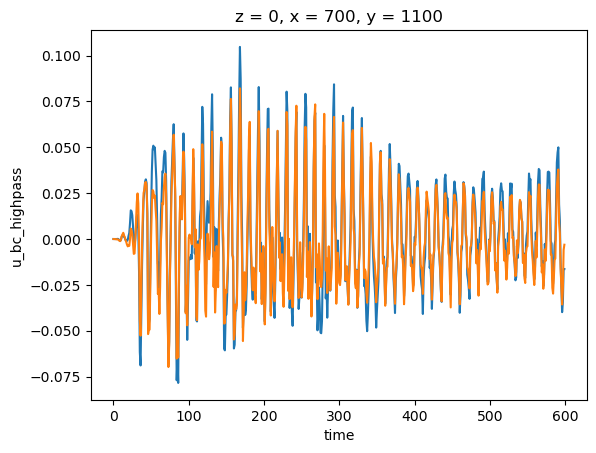

In [107]:
# u_sulu.isel(z=0).plot()
u_bc_sulu.isel(z = 0).plot()
(u_bc_hp_sulu.isel(z = 0)).plot()
# u_bc_hp_sulu.isel(z = 10).plot()
# (p_bc_sulu.isel(z = 0)-p_bc_sulu.isel(z = 0).mean(dim='time')).plot()
# p_bc_hp_sulu.isel(z = 0).plot()
# rho_sulu.isel(z = 0).plot()
# plt.xlim(0,50)

In [118]:
def power_spectral_density_fft(var,fs=1/3600):

    # fs = 5.0
    N = len(var)
    var = scipy.signal.detrend(var, type='linear')
    fft = np.fft.fft(var)
    frequencies = np.fft.fftfreq(N, 1/fs)[:N//2]  # Positive frequencies only
    psd = (1/(fs * N)) * np.abs(fft[:N//2])**2  # PSD
    psd[1:-1] *= 2  # Double non-DC/nyquist components for one-sided spectrum

    return frequencies, psd

/tmp/ipykernel_1026606/2617828033.py:12: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1/(freq1*3600), psd_orig, label='Original',linewidth=3)
/tmp/ipykernel_1026606/2617828033.py:16: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1/(freq5*3600), psd_hp_fft, label='High-pass Filtered FFT', linewidth=3)


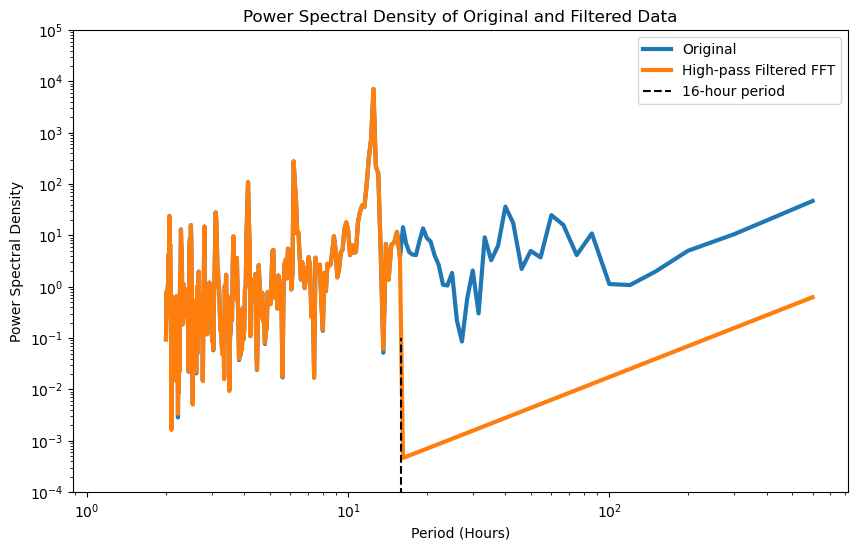

In [122]:
data_u_p1 = v_bc_sulu.isel(z=0).values
data_u_hp_p1 = v_bc_hp_sulu.isel(z=0).values

freq1, psd_orig = power_spectral_density_fft(v_bc_sulu_p1)
# freq2, psd_hp = power_spectral_density_fft(v_hp_0000)
freq2, psd_lp = power_spectral_density_fft(v_lp_0000)
freq3, psd_hp = power_spectral_density_fft(v_hp_0000)
freq4, psd_hp1 = power_spectral_density_fft(v_hp_0001)
freq5, psd_hp_fft = power_spectral_density_fft(v_hp_fft_0000)

plt.figure(figsize=(10,6))
plt.loglog(1/(freq1*3600), psd_orig, label='Original',linewidth=3)
# plt.loglog(1/(freq2*3600), psd_lp, label='Low-pass Filtered', linewidth=3)
# plt.loglog(1/(freq3*3600), psd_hp, label='High-pass Filtered', linewidth=3)
# plt.loglog(1/(freq4*3600), psd_hp1, label='High-pass Filtered 1', linewidth=3)
plt.loglog(1/(freq5*3600), psd_hp_fft, label='High-pass Filtered FFT', linewidth=3)
# plt.plot(1/freq/3600, psd_orig, label='Original',linewidth=3)
# plt.plot(1/freq/3600, psd_band, label='Bandpass Filtered', linewidth=3)
# plt.vlines(10.5, 1e-8, 1e-1, color='k', linestyle='--', label='11-hour period')
# plt.vlines(14.5, 1e-8, 1e-1, color='k', linestyle='--', label='14.5-hour period')
plt.vlines(16, 1e-8, 1e-1, color='k', linestyle='--', label='16-hour period')
# plt.vlines(36, 1e-8, 1e-1, color='k', linestyle='--', label='36-hour period')
# plt.xlim(1/500, 1/1.9)
plt.ylim(1e-4, 1e5)
plt.xlabel('Period (Hours)')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectral Density of Original and Filtered Data')
plt.legend()

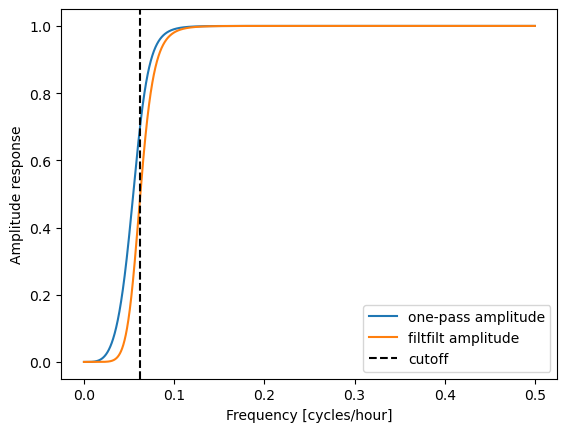

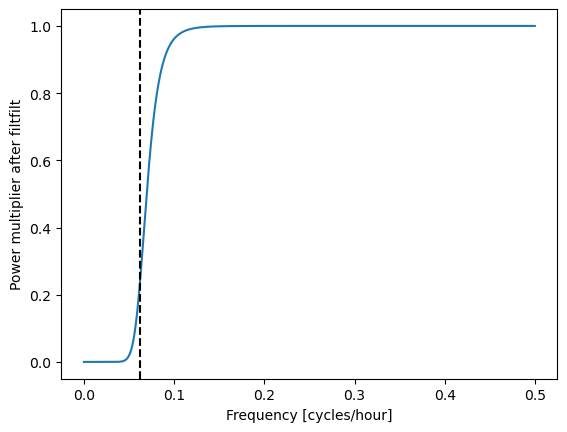

In [93]:
from scipy.signal import butter, freqz

dt = 1.0
fs = 1.0 / dt
fc = 1.0 / 16.0

b, a = butter(4, fc, btype="highpass", fs=fs)

w, h = freqz(b, a, worN=4096, fs=fs)

amp_onepass = np.abs(h)
amp_filtfilt = np.abs(h)**2
power_factor_filtfilt = np.abs(h)**4

plt.figure()
plt.plot(w, amp_onepass, label="one-pass amplitude")
plt.plot(w, amp_filtfilt, label="filtfilt amplitude")
plt.axvline(fc, color="k", linestyle="--", label="cutoff")
plt.xlabel("Frequency [cycles/hour]")
plt.ylabel("Amplitude response")
plt.legend()
plt.show()

plt.figure()
plt.plot(w, power_factor_filtfilt)
plt.axvline(fc, color="k", linestyle="--")
plt.xlabel("Frequency [cycles/hour]")
plt.ylabel("Power multiplier after filtfilt")
plt.show()

In [37]:
# verify FX and FY

fx3d = xr.open_zarr(os.path.join(data_dir, 'Fx.zarr'), consolidated=False)
fy3d = xr.open_zarr(os.path.join(data_dir, 'Fy.zarr'), consolidated=False)

fx = xr.open_zarr(os.path.join(data_dir, 'fx_ver_int_bp.zarr'), consolidated=False)
fy = xr.open_zarr(os.path.join(data_dir, 'fy_ver_int_bp.zarr'), consolidated=False)

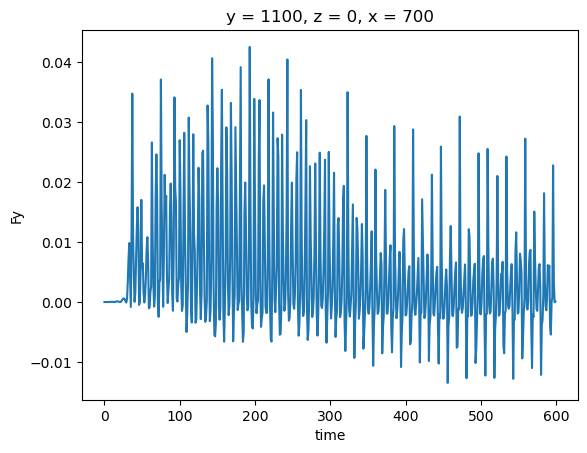

In [5]:
# fx3d.Fx.isel(x = 700, y = 1100, z= 0).plot()
fy3d.Fy.isel(x = 700, y = 1100, z= 0).plot()

Text(0.5, 1.0, 'Mean Baroclinic Energy Flux Vectors')

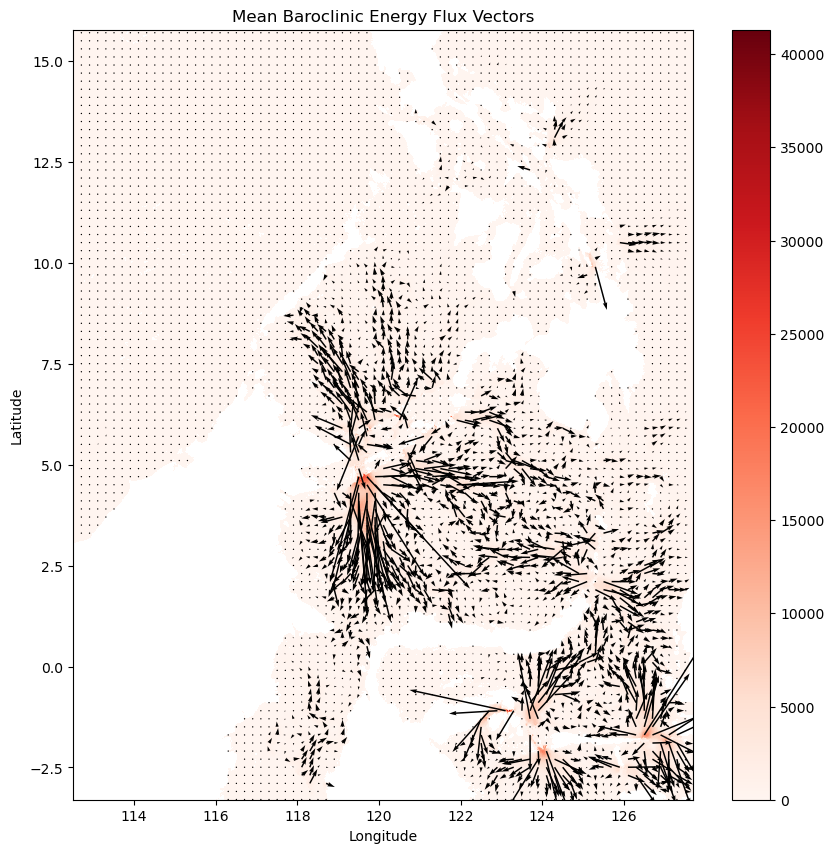

In [38]:
# fxy = np.sqrt(fx.fx_ver_int**2+fy.fy_ver_int**2)

# fxy.isel(time=slice(400,450)).mean(dim='time').plot(vmax=1e-6)
Fx_ver_int_tavg_vint = fx.fx_ver_int.isel(time=slice(400,450)).mean(dim='time')* np.sum(drF[:, np.newaxis, np.newaxis] * hFacW, axis=0)*rho0
Fy_ver_int_tavg_vint = fy.fy_ver_int.isel(time=slice(400,450)).mean(dim='time')* np.sum(drF[:, np.newaxis, np.newaxis] * hFacS, axis=0)*rho0

Fxy_ver_int_mean = np.sqrt(Fx_ver_int_tavg_vint**2 + Fy_ver_int_tavg_vint**2)

plt.figure(figsize=(10,10))
plt.pcolormesh(lon, lat, Fxy_ver_int_mean, cmap='Reds')
plt.colorbar()
plt.quiver(lon[0:-1:20], lat[0:-1:20], Fx_ver_int_tavg_vint[0:-1:20, 0:-1:20], Fy_ver_int_tavg_vint[0:-1:20, 0:-1:20])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mean Baroclinic Energy Flux Vectors')

In [ ]:
# check the background density profile and the reference density profile

rho_sulu = []
for it in tqdm(range(18,550,37)):
    rhoref = xr.open_dataset(os.path.join(f'rhoref_zstar_ctrl_case_ctrl_v3/rhoref_t_{it:03d}.nc'))

    rho_sulu_0 = rhoref.rho_ref.isel(y =1100, x=700).values
    rho_sulu.append(rho_sulu_0)


100%|██████████| 15/15 [00:02<00:00,  6.77it/s]


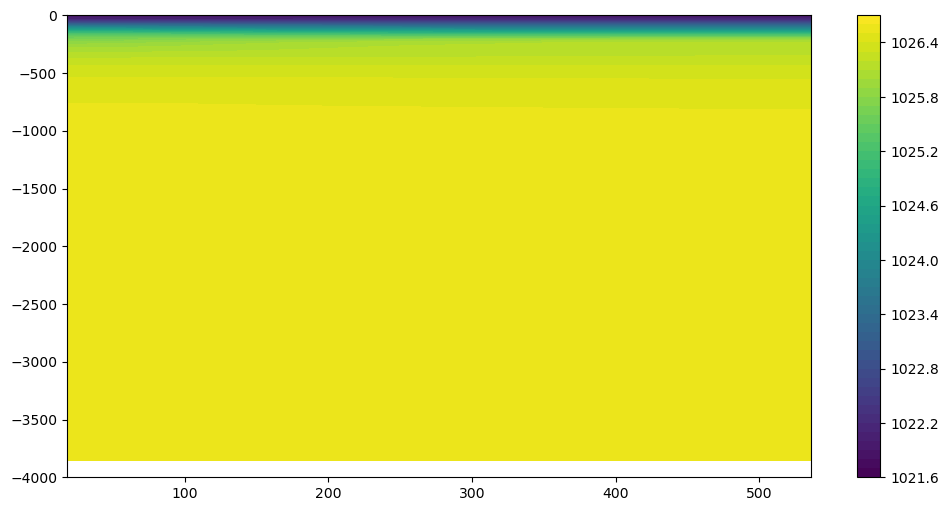

In [41]:
# plt.pcolormesh(np.arange(18,550,37), ds_rho.Z, np.array(rho_sulu).T)
plt.figure(figsize=(12,6))
plt.contourf(np.arange(18,550,37), ds_rho.Z, np.array(rho_sulu).T+1026.5,levels=np.arange(1021.6, 1026.8, 0.1), cmap='viridis')
plt.ylim(-4000, 0)
plt.colorbar()

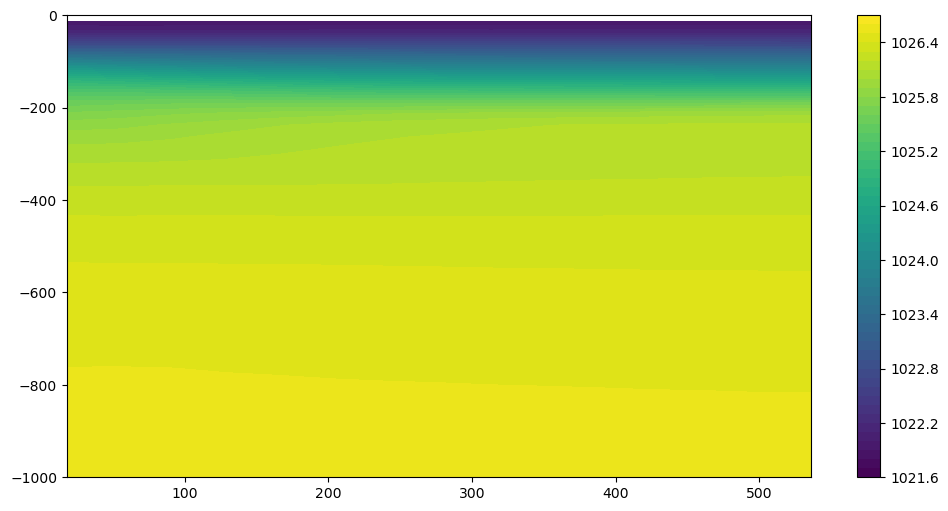

In [42]:
# plt.pcolormesh(np.arange(18,550,37), ds_rho.Z, np.array(rho_sulu).T)
plt.figure(figsize=(12,6))
plt.contourf(np.arange(18,550,37), ds_rho.Z, np.array(rho_sulu).T+1026.5,levels=np.arange(1021.6, 1026.8, 0.1), cmap='viridis')
plt.ylim(-1000, 0)
plt.colorbar()

## 2.2 plot the energy fluxes

### 2.2.1 compare pres and u - ctrl_bot_intens and ctrl_bot_intens_Tsorted

In [11]:

pres_0 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'p_rho_bc.zarr'), consolidated=False)
pres_1 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'p_rho_bc.zarr'), consolidated=False)
pres_0_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'p_rho_bc_bp_semidiurnal.zarr'), consolidated=False)
pres_1_lp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'p_rho_bc_lowpass.zarr'), consolidated=False)
pres_1_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'p_rho_bc_bp_semidiurnal.zarr'), consolidated=False)

pres_0_sulu = pres_0.p_rho_bc.isel(z=0, y=1100, x=700)
pres_1_sulu = pres_1.p_rho_bc.isel(z=0, y=1100, x=700)
pres_0_sulu_bp = pres_0_bp.p_rho_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)
pres_1_sulu_lp = pres_1_lp.p_rho_bc_lowpass.isel(z=0, y=1100, x=700)
pres_1_sulu_bp = pres_1_bp.p_rho_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)

pres_1_sulu_dmean = pres_1_sulu-pres_1_sulu.mean(dim='time')
pres_1_sulu_lp_dmean = pres_1_sulu_lp-pres_1_sulu_lp.mean(dim='time')

Text(0.5, 1.0, 'Comparison of Pressure at Sulu Sea (z=0, y=1100, x=700)')

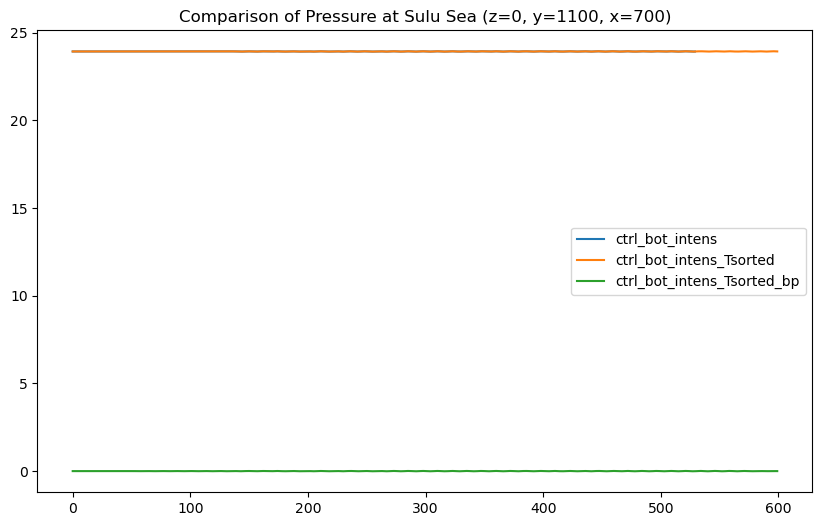

In [12]:
plt.figure(figsize=(10,6))
plt.plot(pres_0_sulu, label='ctrl_bot_intens')
plt.plot(pres_1_sulu, label='ctrl_bot_intens_Tsorted')
plt.legend()
plt.title('Comparison of Pressure at Sulu Sea (z=0, y=1100, x=700)')

(0.0, 550.0)

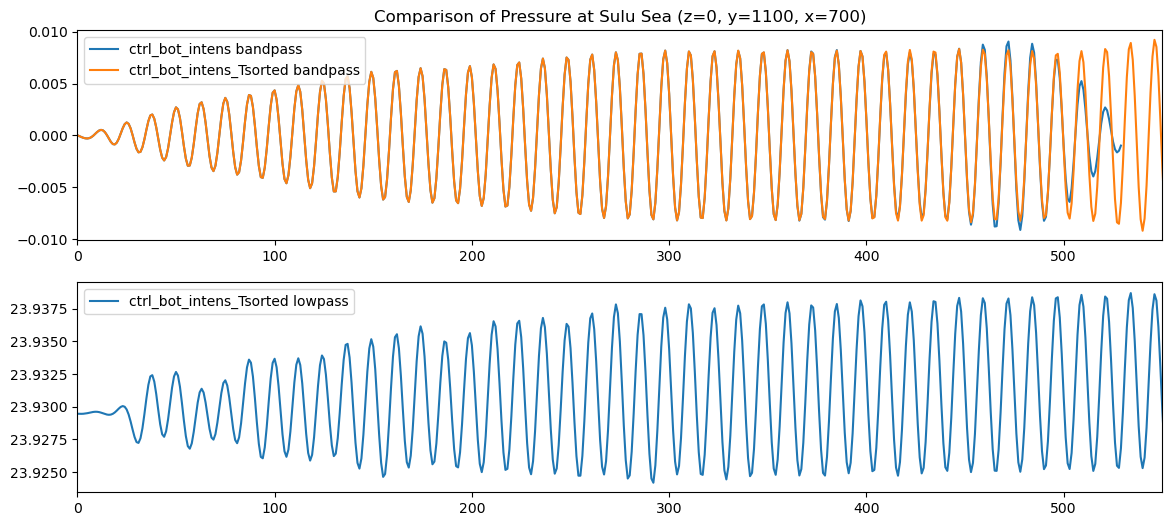

In [13]:
fig, ax = plt.subplots(2,1, figsize=(14,6))
ax[0].plot(pres_0_sulu_bp, label='ctrl_bot_intens bandpass')
ax[0].plot(pres_1_sulu_bp, label='ctrl_bot_intens_Tsorted bandpass')
ax[1].plot(pres_1_sulu_lp, label='ctrl_bot_intens_Tsorted lowpass')
ax[0].legend()
ax[1].legend()
ax[0].set_title('Comparison of Pressure at Sulu Sea (z=0, y=1100, x=700)')
ax[1].set_xlim(0, 550)
ax[0].set_xlim(0, 550)

### 2.2.2 compare velocity / 

In [30]:
u_0 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'u_bc.zarr'), consolidated=False)
u_1 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'u_bc.zarr'), consolidated=False)
u_0_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'u_bc_bp_semidiurnal.zarr'), consolidated=False)
u_1_lp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'u_bc_lowpass.zarr'), consolidated=False)
u_1_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'u_bc_bp_semidiurnal.zarr'), consolidated=False)

u_0_sulu = u_0.u_bc.isel(z=0, y=1100, x=700)
u_1_sulu = u_1.u_bc.isel(z=0, y=1100, x=700)
u_0_sulu_bp = u_0_bp.u_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)
u_1_sulu_lp = u_1_lp.u_bc_lowpass.isel(z=0, y=1100, x=700)
u_1_sulu_bp = u_1_bp.u_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)

Text(0.5, 1.0, 'Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

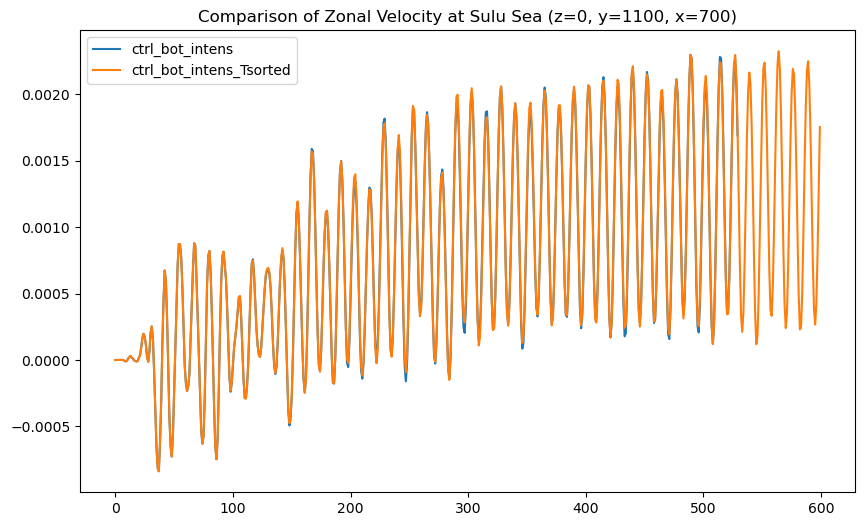

In [152]:
plt.figure(figsize=(10,6))
plt.plot(u_0_sulu, label='ctrl_bot_intens')
plt.plot(u_1_sulu, label='ctrl_bot_intens_Tsorted')
plt.legend()
plt.title('Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

Text(0.5, 1.0, 'Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

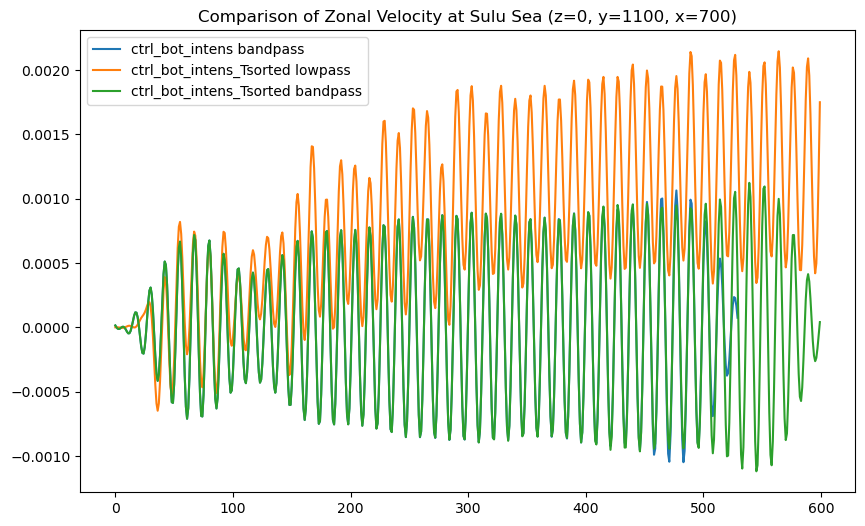

In [31]:
plt.figure(figsize=(10,6))
plt.plot(u_0_sulu_bp, label='ctrl_bot_intens bandpass')
plt.plot(u_1_sulu_lp, label='ctrl_bot_intens_Tsorted lowpass')
plt.plot(u_1_sulu_bp, label='ctrl_bot_intens_Tsorted bandpass')
plt.legend()
plt.title('Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

### 2.2.3 compare rho

In [51]:
ds_rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)
ds_rho_lp = xr.open_zarr(os.path.join(data_dir, 'rho_lowpass.zarr'), consolidated=False)
rho_sulu = ds_rho.rho.isel(z = 10, y = 1100, x=700)
rho_lp_sulu = ds_rho_lp.rho_lowpass.isel(z = 10, y = 1100, x=700)

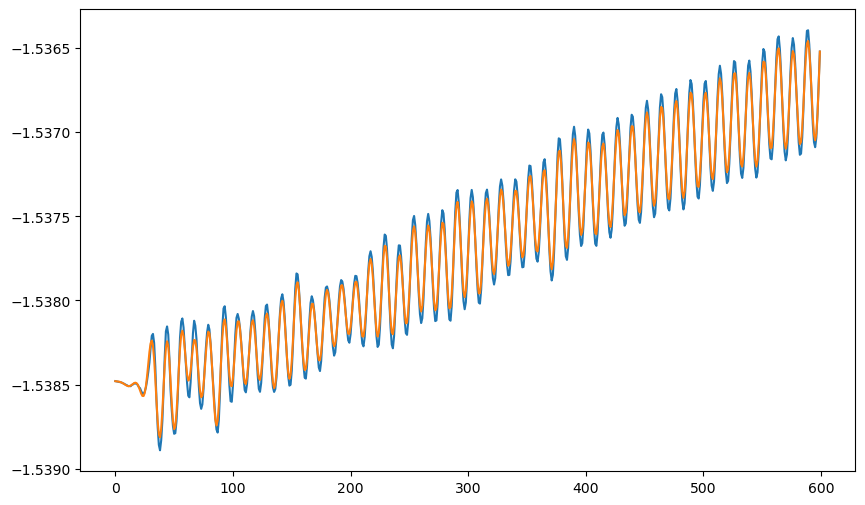

In [53]:
plt.figure(figsize=(10,6))
plt.plot(rho_sulu, label='rho')
plt.plot(rho_lp_sulu, label='rho lowpass')

In [4]:
ke = xr.open_zarr(os.path.join(data_dir, 'ke_bc_highpass.zarr'), consolidated=False)

ke_ver_int = np.sum(ke.ke_bc_highpass.isel(time=slice(400,450)).mean(dim='time')* drF[:, np.newaxis, np.newaxis] * hFacW, axis=0)*rho0 

In [6]:
ke_ver_int

<xarray.DataArray 'ke_bc_highpass' (y: 1908, x: 1520)> Size: 12MB
dask.array<mul, shape=(1908, 1520), dtype=float32, chunksize=(128, 128), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int32 6kB 0 1 2 3 4 5 6 ... 1513 1514 1515 1516 1517 1518 1519
  * y        (y) int32 8kB 0 1 2 3 4 5 6 ... 1901 1902 1903 1904 1905 1906 1907

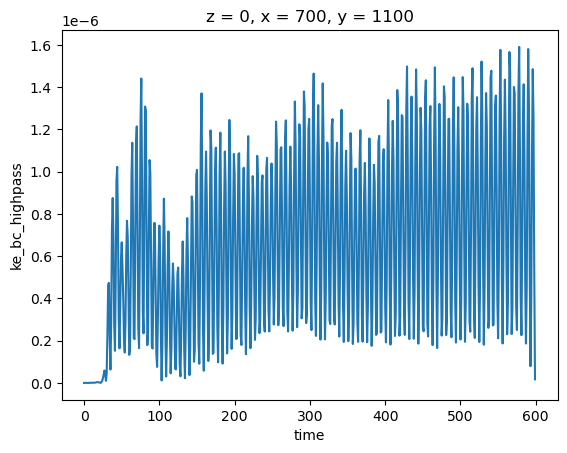

In [7]:
ke.isel(x=700, y=1100, z=0).ke_bc_highpass.plot()

In [21]:
# Fx_ver_int = xr. open_zarr(os.path.join(data_dir, 'fx_ver_int.zarr'), consolidated=False)
# Fy_ver_int = xr. open_zarr(os.path.join(data_dir, 'fy_ver_int.zarr'), consolidated=False)
Fx_ver_int = xr. open_zarr(os.path.join(data_dir, 'fx_ver_int_bp.zarr'), consolidated=False)
Fy_ver_int = xr. open_zarr(os.path.join(data_dir, 'fy_ver_int_bp.zarr'), consolidated=False)


In [7]:
def build_bandpass_filter() -> tuple[np.ndarray, np.ndarray]:
    fs = 1 / 3600
    cutoff1 = 1 / (14.5 * 3600)
    cutoff2 = 1 / (11 * 3600)
    # cutoff = 1 / (10.5 * 3600)
    # wn = [cutoff / (0.5 * fs)]
    wn = [cutoff1 / (0.5 * fs), cutoff2 / (0.5 * fs)]
    return butter(4, wn, btype="band")
b, a = build_bandpass_filter()
Fx_ver_int_lp = filtfilt(b, a, Fx_ver_int.fx_ver_int, axis=0).astype(np.float32, copy=False)

Fy_ver_int_lp = filtfilt(b, a, Fy_ver_int.fy_ver_int, axis=0).astype(np.float32, copy=False)


Text(0.5, 1.0, 'Comparison of Fx Vertical Integral at Sulu Sea (y=1100, x=700)')

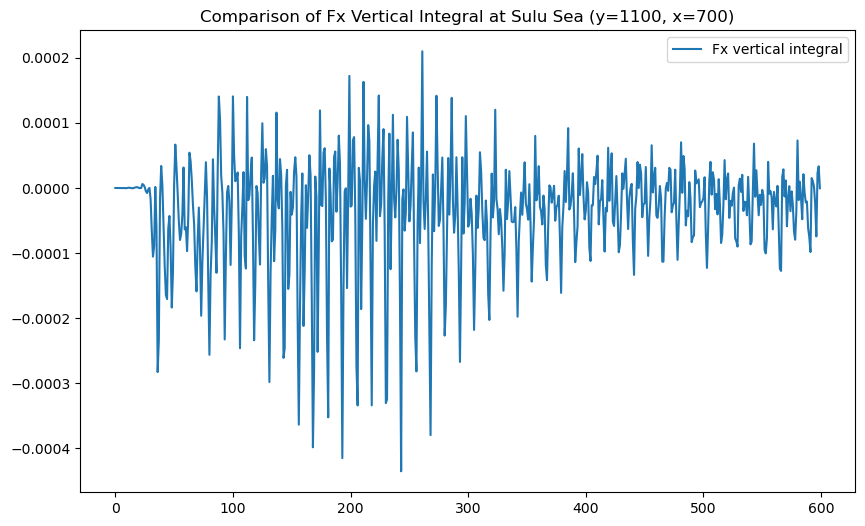

In [22]:
plt.figure(figsize=(10,6))
plt.plot(Fx_ver_int.fx_ver_int.isel(y=1100, x=700), label='Fx vertical integral')
# plt.plot(Fy_ver_int_lp[:,1100,700], label='Fy vertical integral lowpass')
# plt.plot(Fx_ver_int_bp.fx_ver_int.isel(y=1100, x=700), label='Fx vertical integral bandpass')
plt.legend()
plt.title('Comparison of Fx Vertical Integral at Sulu Sea (y=1100, x=700)')

Text(0.5, 1.0, 'Comparison of Fy Vertical Integral at Sulu Sea (y=1100, x=700)')

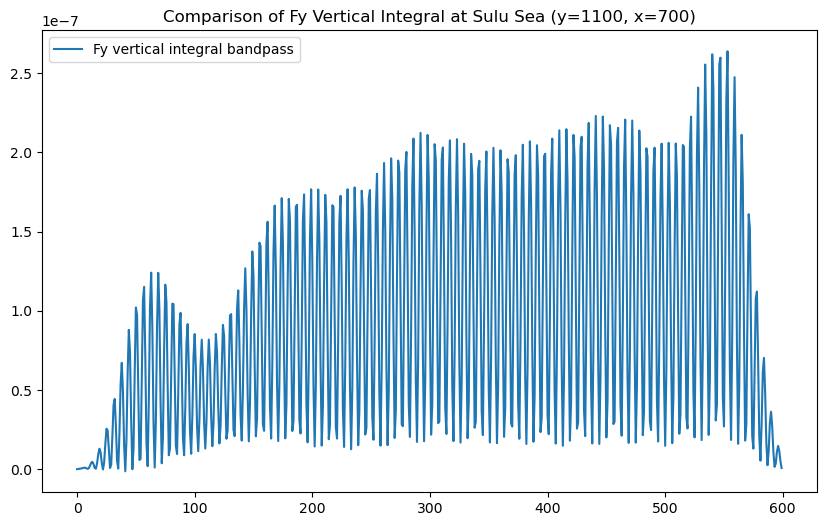

In [41]:
plt.figure(figsize=(10,6))
# plt.plot(Fy_ver_int.fy_ver_int.isel(y=1100, x=700), label='Fy vertical integral')
# plt.plot(Fy_ver_int_lp[:,1100,700], label='Fy vertical integral lowpass')
plt.plot(Fy_ver_int_bp.fy_ver_int.isel(y=1100, x=700), label='Fy vertical integral bandpass')
plt.legend()
plt.title('Comparison of Fy Vertical Integral at Sulu Sea (y=1100, x=700)')

In [23]:
Fy_ver_int_tavg = Fy_ver_int.fy_ver_int.isel(time = slice(450,500)).mean(dim='time')
Fx_ver_int_tavg = Fx_ver_int.fx_ver_int.isel(time = slice(450,500)).mean(dim='time')
# Fy_ver_int_tavg = Fy_ver_int_bp.fy_ver_int.isel(time=slice(450, 500)).mean(dim='time')
# Fx_ver_int_tavg = Fx_ver_int_bp.fx_ver_int.isel(time=slice(450, 550)).mean(dim='time')

drF = ds_grid.drF.values
hFacC = ds_grid.hFacC.values
hFacW = ds_grid.hFacW.values
hFacS = ds_grid.hFacS.values

Fx_ver_int_tavg_vint = Fx_ver_int_tavg * np.sum(drF[:, np.newaxis, np.newaxis] * hFacW, axis=0)*rho0
Fy_ver_int_tavg_vint = Fy_ver_int_tavg * np.sum(drF[:, np.newaxis, np.newaxis] * hFacS, axis=0)*rho0

## 2.3 get mean APE in the Sulu Sea

In [8]:
ds_rhoref0 = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v3/rhoref_t_018.nc')
ds_rhoref1 = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v3/rhoref_t_129.nc')

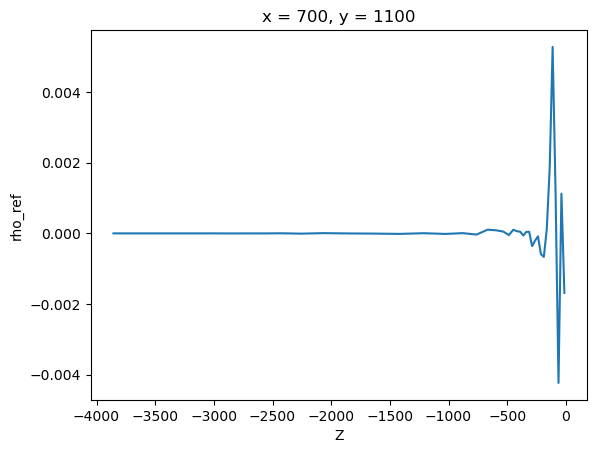

In [11]:

(ds_rhoref0.rho_ref.sel(x=700, y=1100)-ds_rhoref1.rho_ref.sel(x=700, y=1100)).plot()
# ds_rhoref1.rho_ref.sel(x=700, y=1100).plot()

In [28]:
zstar = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v3/zstar_t_018.nc')
rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)
theta = xr.open_zarr(os.path.join(data_dir, 'theta.zarr'), consolidated=False)

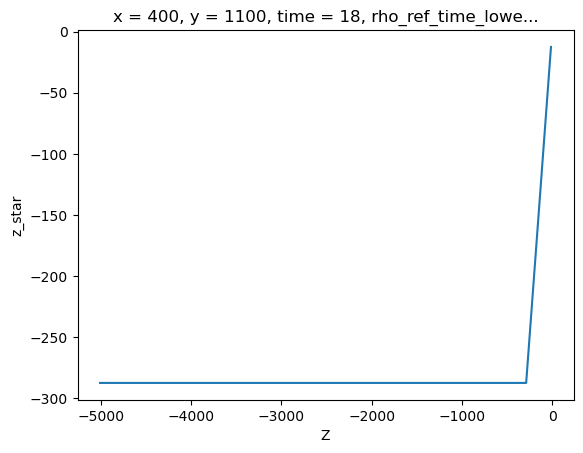

In [22]:
zstar.z_star.sel(x=400, y=1100).plot()

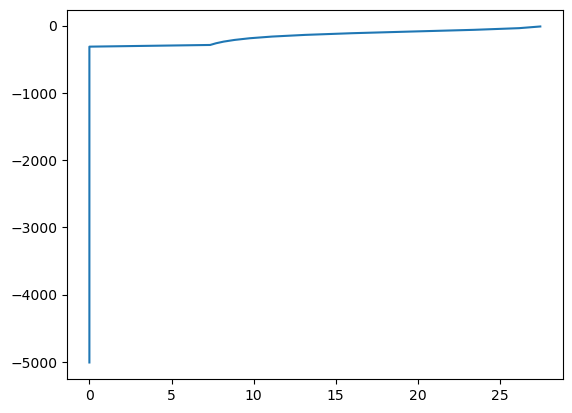

In [29]:
plt.plot(theta.theta.isel(time=0, y=1100, x=400), z_centers)

In [76]:
zarr_file = '/storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output'

rho = xr.open_zarr(os.path.join(zarr_file, 'rho.zarr'), consolidated=False)
rho_mean = rho.isel(time=slice(240, 280)).mean(dim=['time'])

rho_mean_sulu = rho_mean.isel(y=1100, x=slice(570, 970))
# save rho_mean to zarr
rho_mean_sulu.to_netcdf('rho_mean_sulu_sec.nc', mode='w')


In [77]:

# i_min = 836
# i_max = 1579
# j_min = 508
# j_max = 1077
CASE_DIR = f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/'

print(f"Processing mean rho fields...")

# rho_t = xr.DataArray(rho_mean_sulu.rho.values, dims=("Z", "XC"))
rho_t = xr.open_dataset('rho_mean_sulu_sec.nc').rho.values
# drF = ds_mask["drF"] # center

# spatial_dims = rho_t.dims
# k_dim = spatial_dims[0]

_, ref = compute_background_PE(rho_t, rA, hFacC, vol, mask, V_ref_k, z_centers, )   # or rho from equation of state

zstar_all = np.full(rho_t.shape, np.nan, dtype=float)
zstar_all.ravel()[mask] = ref["zstar"]

theta_ref_ds = xr.Dataset(
    data_vars={
        "z_star": (("Z", "x"), zstar_all),
        "rho_ref": (("Z",), ref["rho_ref"]),
    },
    coords={"Z": z_centers,
            "x": lon_sec, 
            "y": lat_sec,}
)

# theta_ref_ds.to_netcdf(case_folder / f"rhoref_zstar_t_{it:03d}.nc", mode="w")
theta_ref_ds.to_netcdf("rhoref_zstar_mean.nc", mode="w")

# del ds_sn

Processing mean rho fields...


/tmp/ipykernel_2710620/1151127187.py:147: RuntimeWarning: invalid value encountered in scalar divide
  rho_ref[K-1-kk] = sum_rhoV / V_target  # assign back in top->bottom order


## 3. get APE based on Kang and Fringer (2011)

In [24]:
## get vertical integrated APE2
ds_ape2_v3 = xr.open_zarr('zarr_output/APE2.zarr', consolidated=False)
ke = xr.open_zarr('zarr_output/ke_bc_highpass.zarr', consolidated=False)

# i_min = 836
# i_max = 1579
# j_min = 508
# j_max = 1077
# coordinates and grid info for the section
ds = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/ctrl_tests/case_ctrl_bot_intensify_Tsorted_2/', prefix=['outs_sn'], iters=[0])

# lon_sec = ds.XC.isel(XC=slice(j_min, j_max+1)).values
# lat_sec = ds.YC.isel(YC=slice(i_min, i_max+1)).values
lon_sec = ds.XC.values
lat_sec = ds.YC.values

drF = ds.drF.values
# hFacC = ds.hFacC.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).values
hFacC = ds.hFacC.values
z_centers = ds.Z.values

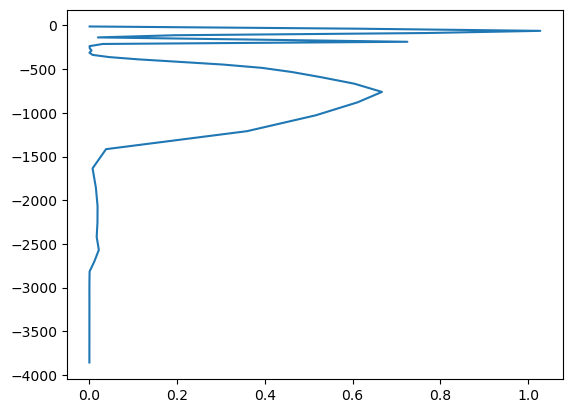

In [25]:

plt.plot(ds_ape2_v3.APE2.isel(time=450, Z=slice(0, None), y=1100, x=700).values,z_centers[0:],  label='APE2')
# plt.ylim(-5000, 0)
# plt.title("APE2")
# plt.vlines(0, -5000, 0,'k', linestyles='--')
# plt.xlabel("APE2 (J/m^3)")
# plt.ylabel("Z (m)")

In [26]:
# APE2_v3_vint = np.zeros((50, len(lat_sec), len(lon_sec)))
APE2_v3_vint = np.zeros((50, len(lat_sec), len(lon_sec)))
for it in tqdm(range(400, 450)):
    # APE2_v3_vint[it-400] = np.nansum(ds_ape2_v3.APE2.isel(time=it, Z=slice(0, None))* drF[0:, np.newaxis, np.newaxis] * hFacC[0:, :, :], axis=0)
    APE2_v3_vint[it-400] = np.nansum(ds_ape2_v3.APE2.isel(time=it, )* drF[:, np.newaxis, np.newaxis] * hFacC[:, :, :], axis=0)


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [09:15<00:00, 11.11s/it]


In [27]:
KE_vint = np.zeros((50, len(lat_sec), len(lon_sec)))
for it in tqdm(range(400, 450)):
    KE_vint[it-400] = np.nansum(ke.ke_bc_highpass.isel(time=it, )* drF[:, np.newaxis, np.newaxis] * hFacC[:, :, :], axis=0)*rho0

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [13:33<00:00, 16.28s/it]


In [28]:
cg = xr.open_dataset('first_phase_speed_sulu.nc')
cg

<xarray.Dataset> Size: 58MB
Dimensions:            (y: 1908, x: 1520)
Coordinates:
  * y                  (y) int64 15kB 0 1 2 3 4 5 ... 1903 1904 1905 1906 1907
  * x                  (x) int64 12kB 0 1 2 3 4 5 ... 1515 1516 1517 1518 1519
Data variables:
    first_phase_speed  (y, x) float64 23MB ...
    cg                 (y, x) float64 23MB ...
    depth              (y, x) float32 12MB ...

In [29]:
Eflux_avail = np.mean(APE2_v3_vint+KE_vint, axis=0)*cg.cg

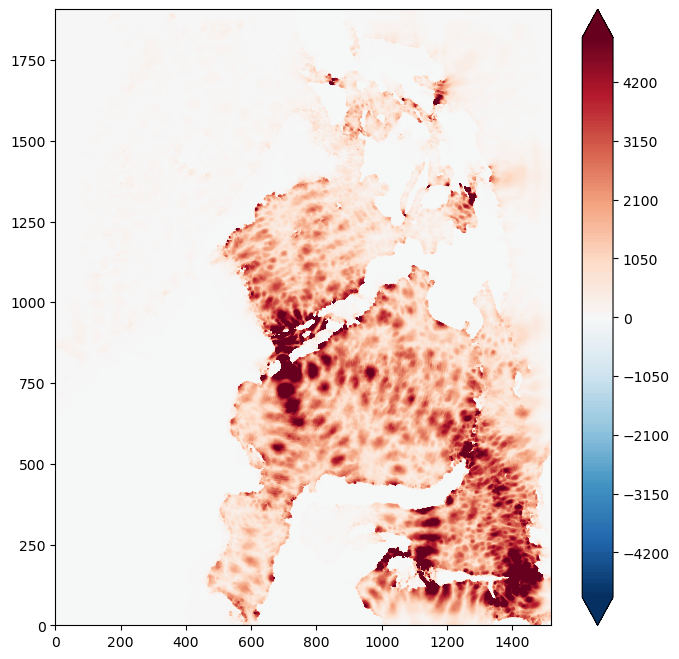

In [55]:
plt.figure(figsize=(8,8))
plt.contourf(np.mean(APE2_v3_vint,axis=0), cmap='RdBu_r', vmin=-5e3 , vmax=5e3, levels = np.arange(-5e3, 5.05e3, 0.05e3), extend='both')
plt.colorbar()

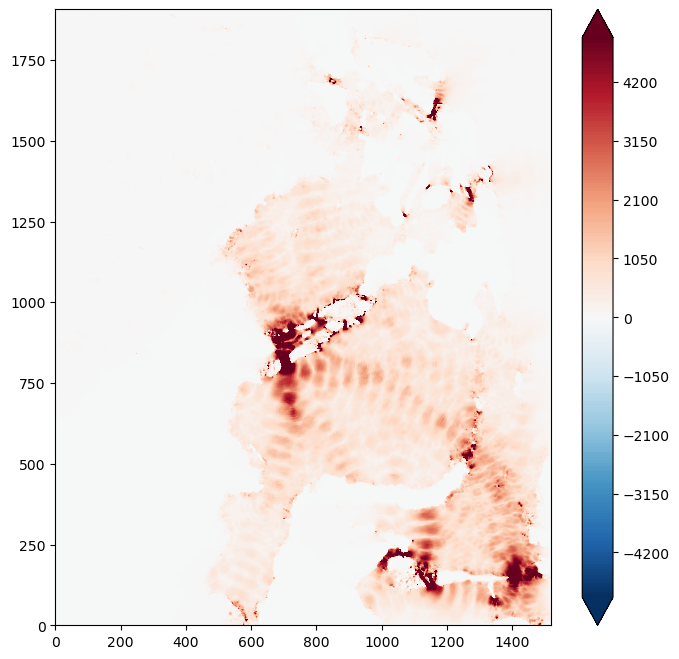

In [56]:
plt.figure(figsize=(8,8))
plt.contourf(np.mean(KE_vint,axis=0), cmap='RdBu_r', vmin=-5e3 , vmax=5e3, levels = np.arange(-5e3, 5.05e3, 0.05e3), extend='both')
plt.colorbar()

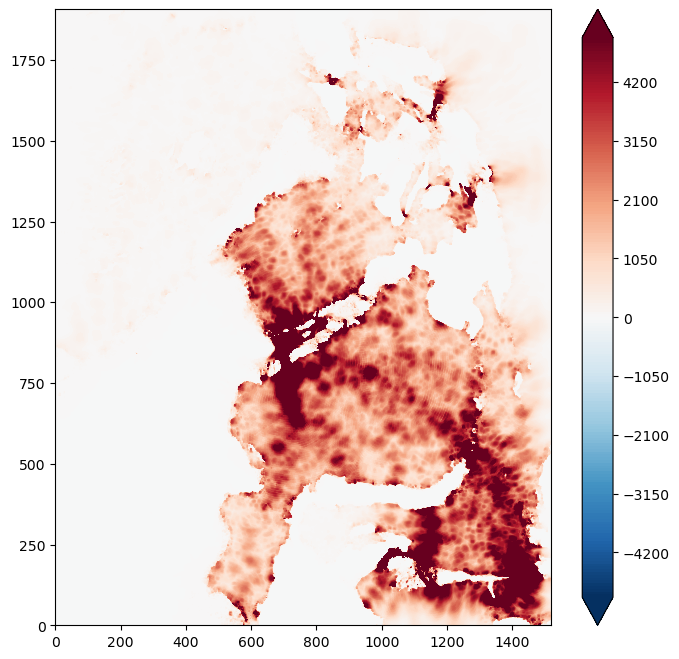

In [58]:
plt.figure(figsize=(8,8))
plt.contourf(np.mean(APE2_v3_vint+KE_vint, axis=0), cmap='RdBu_r', vmin=-5e3 , vmax=5e3, levels = np.arange(-5e3, 5.05e3, 0.05e3), extend='both')
plt.colorbar()

Text(0.5, 1.0, 'Available Energy Flux (W/m^2)')

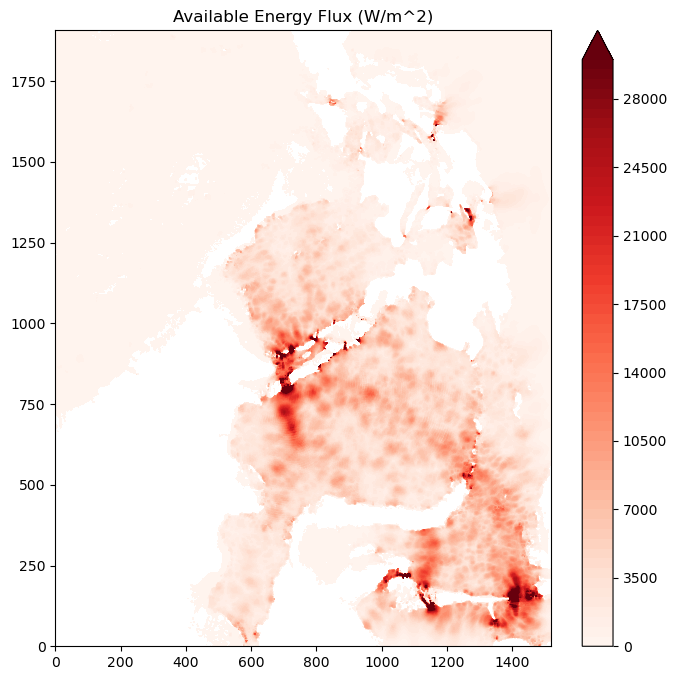

In [67]:
plt.figure(figsize=(8,8))
plt.contourf(Eflux_avail, cmap='Reds', vmin=0, vmax=3e4, levels=np.arange(0, 3.05e4, 0.05e4), extend='max')
plt.colorbar()
plt.title('Available Energy Flux (W/m^2)')

Text(0.5, 1.0, 'Energy Flux (W/m^2)')

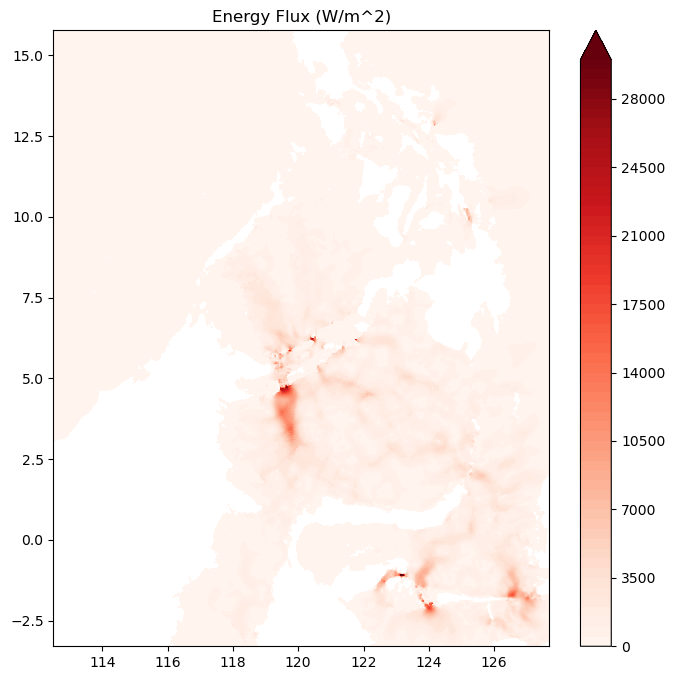

In [39]:
plt.figure(figsize=(8,8))
plt.contourf(lon, lat, Fxy_ver_int_mean, cmap='Reds', vmin=0, vmax=3e4, levels=np.arange(0, 3.05e4, 0.05e4), extend='max')
plt.colorbar()
plt.title( 'Energy Flux (W/m^2)')

In [40]:
# ratio
ratio = Fxy_ver_int_mean.values / Eflux_avail.values

Text(0.5, 1.0, 'ratio of baroclinic energy flux to available energy flux')

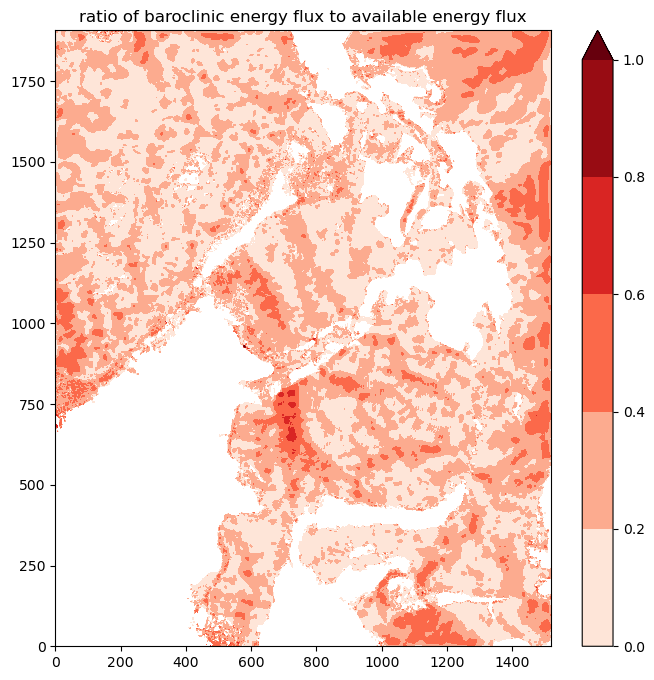

In [42]:
plt.figure(figsize=(8,8))
plt.contourf(ratio, cmap='Reds', vmin=0, vmax=1, levels=np.arange(0, 1.05, 0.2), extend='max')
plt.colorbar()
plt.title('ratio of baroclinic energy flux to available energy flux')

In [7]:
# check rho_ref and z_star

rho_ref_2 = np.zeros((15, len(z_centers)))
for it in tqdm(range(15)):
    kt = it*37 + 18
    print(kt)
    ds_rhoref0 = xr.open_dataset(f'rhoref_zstar_ctrl_case_ctrl_v3/rhoref_t_{kt:03d}.nc')

    rho_ref_2[it, :] = ds_rhoref0.rho_ref.sel(x=900, y=1100).values

  0%|          | 0/15 [00:00<?, ?it/s]

18


  7%|▋         | 1/15 [00:06<01:32,  6.58s/it]

55


 13%|█▎        | 2/15 [00:11<01:10,  5.46s/it]

...

 87%|████████▋ | 13/15 [01:11<00:11,  5.59s/it]

499


 93%|█████████▎| 14/15 [01:16<00:05,  5.63s/it]

536


100%|██████████| 15/15 [01:23<00:00,  5.57s/it]


In [5]:
## check the background density profile and the reference density profile

# check rho_ref and z_star

rho_ref = np.zeros((46, len(z_centers)))
for it in tqdm(range(46)):
    kt = it*13 + 6
    ds_rhoref0 = xr.open_dataset(f'rhoref_zstar_ctrl_case_ctrl_v3_1tidal/rhoref_t_{kt:03d}.nc')

    rho_ref[it, :] = ds_rhoref0.rho_ref.sel(x=900, y=1100).values

100%|██████████| 46/46 [03:40<00:00,  4.80s/it]


([<matplotlib.axis.XTick at 0x153910461490>,
 [Text(6, 0, '6'),
  Text(19, 0, '19'),
  Text(32, 0, '32'),
  Text(45, 0, '45'),
  Text(58, 0, '58'),
  Text(71, 0, '71'),
  Text(84, 0, '84'),
  Text(97, 0, '97'),
  Text(110, 0, '110'),
  Text(123, 0, '123'),
  Text(136, 0, '136'),
  Text(149, 0, '149'),
  Text(162, 0, '162'),
  Text(175, 0, '175'),
  Text(188, 0, '188'),
  Text(201, 0, '201'),
  Text(214, 0, '214'),
  Text(227, 0, '227'),
  Text(240, 0, '240'),
  Text(253, 0, '253'),
  Text(266, 0, '266'),
  Text(279, 0, '279'),
  Text(292, 0, '292'),
  Text(305, 0, '305'),
  Text(318, 0, '318'),
  Text(331, 0, '331'),
  Text(344, 0, '344'),
  Text(357, 0, '357'),
  Text(370, 0, '370'),
  Text(383, 0, '383'),
  Text(396, 0, '396'),
  Text(409, 0, '409'),
  Text(422, 0, '422'),
  Text(435, 0, '435'),
  Text(448, 0, '448'),
  Text(461, 0, '461'),
  Text(474, 0, '474'),
  Text(487, 0, '487'),
  Text(500, 0, '500'),
  Text(513, 0, '513'),
  Text(526, 0, '526'),
  Text(539, 0, '539'),
  Text(

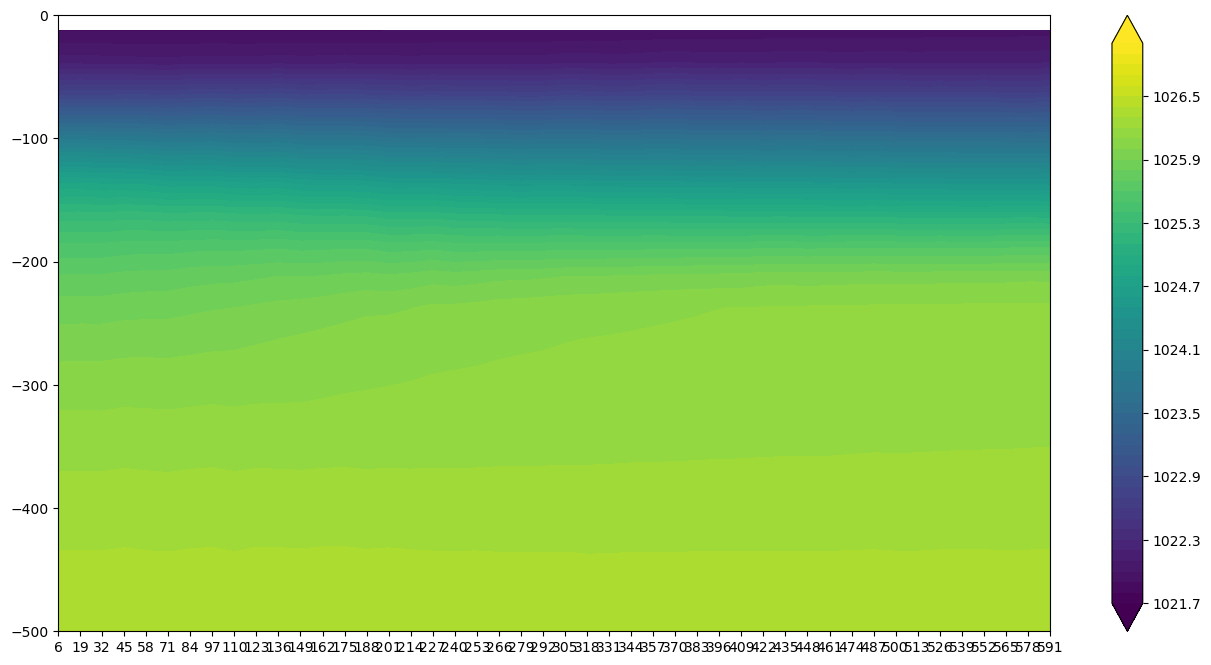

In [8]:
plt.figure(figsize=(16,8))
t_ref = np.arange(6, 6 + 13 * rho_ref.shape[0], 13)
plt.contourf(t_ref, z_centers, 1026.5+(rho_ref).T,levels = 1026.5+np.arange(-4.8, 0.6, 0.1), extend='both')
plt.ylim(-500, 0)
plt.colorbar()
plt.xticks(t_ref, labels=t_ref)
# plt.grid()

Text(0.5, 1.0, 'Comparison of rho and rho_ref at Sulu Sea (z=262.5m)')

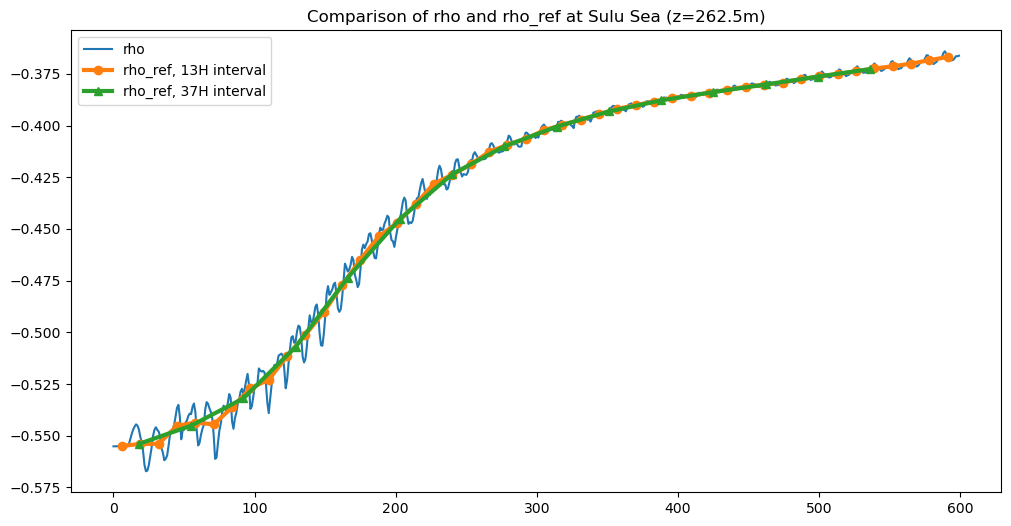

In [10]:
rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)


plt.figure(figsize=(12,6))
plt.plot(rho.isel(x=900, y=1100, z=10).rho.values, label='rho')
plt.plot(np.arange(6,599,13), rho_ref[:,10], 'o-',label='rho_ref, 13H interval', linewidth=3)
plt.plot(np.arange(18, 540, 37), rho_ref_2[:,10], '^-', label='rho_ref, 37H interval', linewidth=3)
plt.legend()
plt.title('Comparison of rho and rho_ref at Sulu Sea (z=262.5m)')

(-0.4, -0.35)

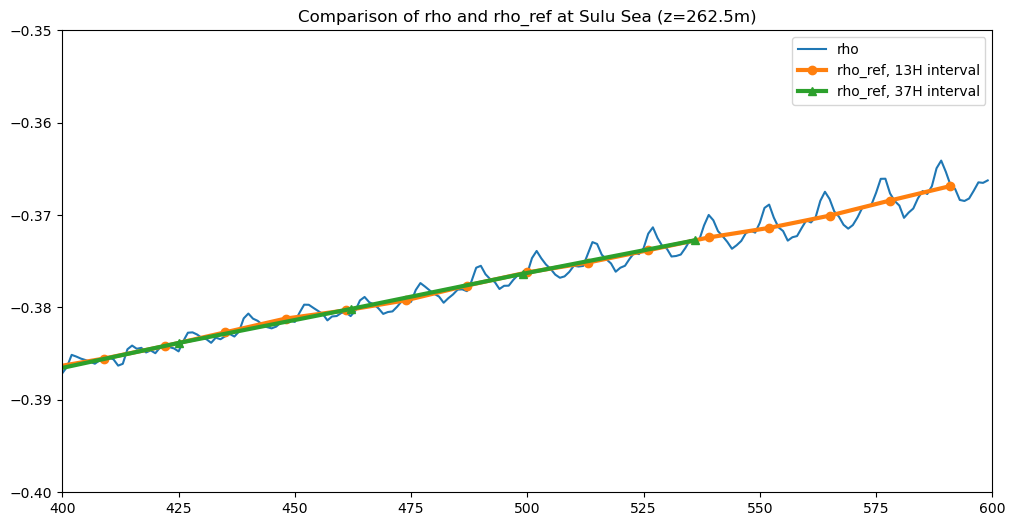

In [11]:
rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)


plt.figure(figsize=(12,6))
plt.plot(rho.isel(x=900, y=1100, z=10).rho.values, label='rho')
plt.plot(np.arange(6,599,13), rho_ref[:,10], 'o-',label='rho_ref, 13H interval', linewidth=3)
plt.plot(np.arange(18, 540, 37), rho_ref_2[:,10], '^-', label='rho_ref, 37H interval', linewidth=3)
plt.legend()
plt.title('Comparison of rho and rho_ref at Sulu Sea (z=262.5m)')

plt.xlim(400, 600)
plt.ylim(-0.4,-0.35)